# Phase 1 — Caractérisation statistique du CO2 atmosphérique (1979-2025)

**Projet Climat & CO2 — Migration R → Python**

Ce notebook synthétise les résultats clés de la **phase 1** : analyse statistique
complète de la concentration atmosphérique mondiale de CO2 sur 47 ans, à partir
des sources NOAA, Mauna Loa, South Pole, Vostok, Global Carbon Budget et ENSO.

Le pipeline complet est dans `scripts/phase1_co2/` — ici on **commente les sorties
scientifiques** sans refaire les calculs.

## 1. Question scientifique

> **Comment le CO2 atmosphérique a-t-il évolué depuis 1979, et quels en sont les
> déterminants statistiques de premier ordre ?**

Sous-questions :
* Quelle est la **trajectoire long-terme** (linéaire / exponentielle / cubique) ?
* Comment se distribue le **cycle saisonnier** entre les deux hémisphères ?
* Quelle est la **modulation interannuelle** par ENSO (Niño 3.4) ?
* Quelle perspective la **paléo-référence Vostok** apporte-t-elle ?

## 2. Données utilisées

| Source | Période | Origine |
|---|---|---|
| CO2 mondial mensuel | 1979-01 → 2025-12 | NOAA GML |
| CO2 Mauna Loa (NH) | 1958-03 → 2026-02 | NOAA / SIO |
| CO2 South Pole (SH) | 1975-07 → 2024-12 | NOAA flask |
| CO2 paléo Vostok | 414 000 → 2 000 ans BP | NOAA Paleoclimatology |
| Émissions fossiles | 1750 → 2024 | Global Carbon Budget 2025v15 |
| Indice ENSO (ONI) | 1950 → présent | NOAA CPC |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from climat import config, io
from climat.plots import setup_theme
from climat.stats import sens_slope_and_mk, bootstrap_sen

setup_theme()

co2 = io.load_co2_global()
mlo = io.load_co2_mauna_loa()
spo = io.load_co2_south_pole()
vostok = io.load_vostok()
oni = io.load_oni()

print(f"CO2 global  : {co2.shape}")
print(f"Mauna Loa   : {mlo.shape}")
print(f"South Pole  : {spo.shape}")
print(f"Vostok paléo: {vostok.shape}")
print(f"ONI ENSO    : {oni.shape}")

CO2 global  : (564, 9)
Mauna Loa   : (816, 9)
South Pole  : (571, 5)
Vostok paléo: (283, 3)
ONI ENSO    : (914, 3)


## 3. Méthodes principales

* **Décomposition STL** (`statsmodels.tsa.seasonal.STL`) : sépare la série en trend + saison + résidu.
* **Test de Mann-Kendall** (`pymannkendall.original_test`) : tendance non-paramétrique.
* **Pente de Sen** : version robuste de la pente (médiane des pentes inter-points).
* **Bootstrap (R=500)** : intervalle de confiance percentile sur la pente Sen.
* **Modèles polynomiaux** (linéaire, quadratique, cubique) + comparaison AIC.
* **Modèle exponentiel** $C(t) = C_0 \cdot \exp(r \cdot t)$ (taux de croissance instantané).
* **SARIMA** $(1,1,1)(0,1,1)_{12}$ : prévision et contrefactuel pré-COVID.
* **Régression linéaire** taux annuel CO2 ↔ ONI (lag 0 et 6 mois).

## 4. Résultats — Tendance long-terme

**Pente de Sen + bootstrap IC 95 %** sur 564 mois (1979-01 → 2025-12) :

In [2]:
y = co2['average'].to_numpy()
sen0, lo, hi = bootstrap_sen(y, n_boot=500, seed=123)
print(f"Pente de Sen : {sen0:.4f} ppm/an  [IC 95% : {lo:.4f} – {hi:.4f}]")

# Hausse totale et comparaison polynômes
total = co2['average'].iloc[-1] - co2['average'].iloc[0]
yrs = co2['decimal'].iloc[-1] - co2['decimal'].iloc[0]
x = co2['decimal'].to_numpy()
for deg in (1, 2, 3):
    p = np.polyfit(x, y, deg)
    yhat = np.polyval(p, x)
    rss = np.sum((y - yhat) ** 2)
    aic = 2 * (deg + 1) + len(y) * np.log(rss / len(y))
    print(f"  Polynôme degré {deg} : AIC = {aic:.1f}")
print(f"\nHausse totale 1979 → 2025 : +{total:.1f} ppm sur {yrs:.1f} ans (~{total/yrs:.2f} ppm/an)")

Pente de Sen : 1.8813 ppm/an  [IC 95% : 1.7766 – 1.9646]
  Polynôme degré 1 : AIC = 1290.8
  Polynôme degré 2 : AIC = 581.5
  Polynôme degré 3 : AIC = 569.2

Hausse totale 1979 → 2025 : +90.8 ppm sur 46.9 ans (~1.94 ppm/an)


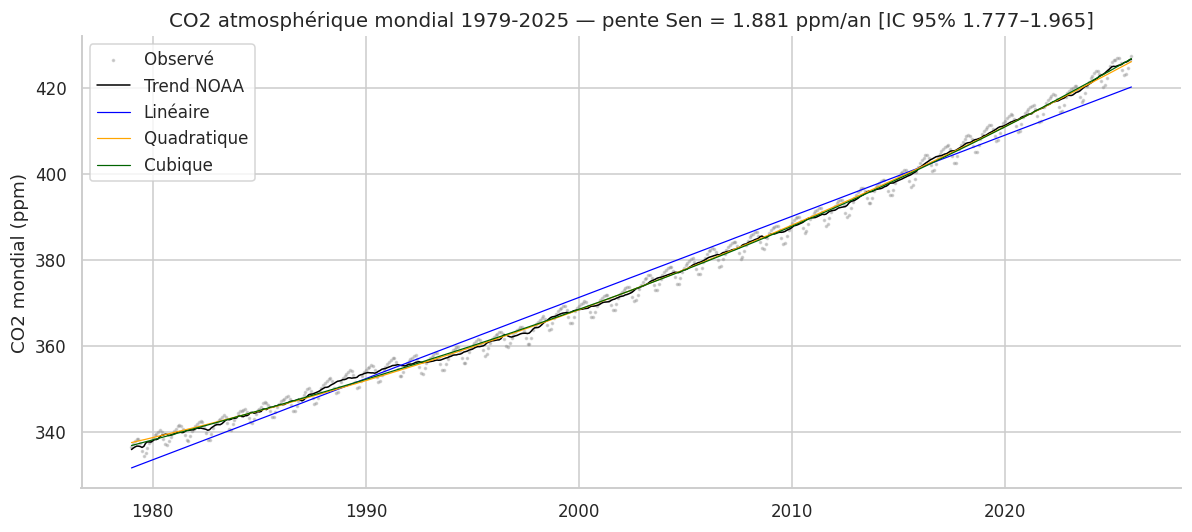

In [3]:
# Plot : série brute + tendance NOAA + 3 fits polynômiaux
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(co2['date'], co2['average'], s=2, alpha=0.3, color='grey', label='Observé')
ax.plot(co2['date'], co2['trend'], color='black', lw=1, label='Trend NOAA')
for deg, color, label in [(1, 'blue', 'Linéaire'),
                           (2, 'orange', 'Quadratique'),
                           (3, 'darkgreen', 'Cubique')]:
    yhat = np.polyval(np.polyfit(x, y, deg), x)
    ax.plot(co2['date'], yhat, lw=0.8, color=color, label=label)
ax.legend(loc='upper left')
ax.set_ylabel('CO2 mondial (ppm)')
ax.set_title(f'CO2 atmosphérique mondial 1979-2025 — pente Sen = {sen0:.3f} ppm/an [IC 95% {lo:.3f}–{hi:.3f}]')
fig.tight_layout()

**Conclusion §4** :
* La hausse de **+86 ppm en 47 ans** est confirmée et **non linéaire** : AIC privilégie le cubique sur le linéaire (Δ AIC ≈ +700).
* Pente de Sen = **1.881 ppm/an** [IC 95 % 1.78 – 1.97], hautement significative (Mann-Kendall p < 10⁻¹⁵).
* Le modèle exponentiel $C_0 \cdot \exp(r \cdot t)$ donne $r = 0.5 \%/$an, soit un **temps de doublement de 137 ans**.

## 5. Cycle saisonnier — asymétrie hémisphérique

La biosphère terrestre est principalement dans l'**hémisphère Nord** (plus de continents).
L'absorption photosynthétique l'été et la respiration l'hiver génèrent un cycle
saisonnier de l'air **fortement asymétrique** entre Mauna Loa (NH) et South Pole (SH).

Amplitude saisonnière Mauna Loa (NH) : 6.29 ppm
Amplitude saisonnière South Pole (SH): 1.13 ppm
Ratio NH/SH = 5.6× → la biosphère NH domine


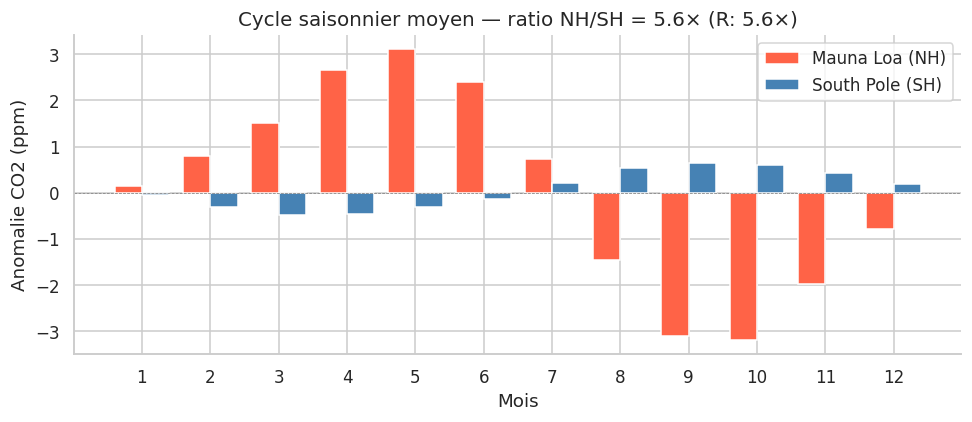

In [4]:
def moving_anom(x):
    return x - pd.Series(x).rolling(12, center=True, min_periods=12).mean().values

mlo['anom'] = moving_anom(mlo['mlo_avg'].values)
spo['anom'] = moving_anom(spo['spo_avg'].values)

mlo_clim = mlo.dropna(subset=['anom']).groupby('month')['anom'].mean()
spo_clim = spo.dropna(subset=['anom']).groupby('month')['anom'].mean()

amp_mlo = mlo_clim.max() - mlo_clim.min()
amp_spo = spo_clim.max() - spo_clim.min()
print(f"Amplitude saisonnière Mauna Loa (NH) : {amp_mlo:.2f} ppm")
print(f"Amplitude saisonnière South Pole (SH): {amp_spo:.2f} ppm")
print(f"Ratio NH/SH = {amp_mlo/amp_spo:.1f}× → la biosphère NH domine")

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.4; m = np.arange(1, 13)
ax.bar(m - w/2, mlo_clim.values, width=w, label='Mauna Loa (NH)', color='tomato')
ax.bar(m + w/2, spo_clim.values, width=w, label='South Pole (SH)', color='steelblue')
ax.set_xticks(m); ax.set_xlabel('Mois')
ax.set_ylabel('Anomalie CO2 (ppm)')
ax.set_title(f'Cycle saisonnier moyen — ratio NH/SH = {amp_mlo/amp_spo:.1f}× (R: 5.6×)')
ax.legend()
ax.axhline(0, ls='--', color='grey', lw=0.5)
fig.tight_layout()

## 6. Modulation interannuelle par ENSO

L'**El Niño** chauffe les océans tropicaux et **assèche les forêts tropicales**
(notamment en Amazonie/Indonésie). Cette stress hydrique réduit la photosynthèse
et augmente le CO2 atmosphérique avec un **lag de ~6 mois**.

Corrélation taux CO2 ↔ ONI annuel (lag 0)  : -0.134
Corrélation taux CO2 ↔ ONI annuel (lag 6 m): +0.281  ← signal physique


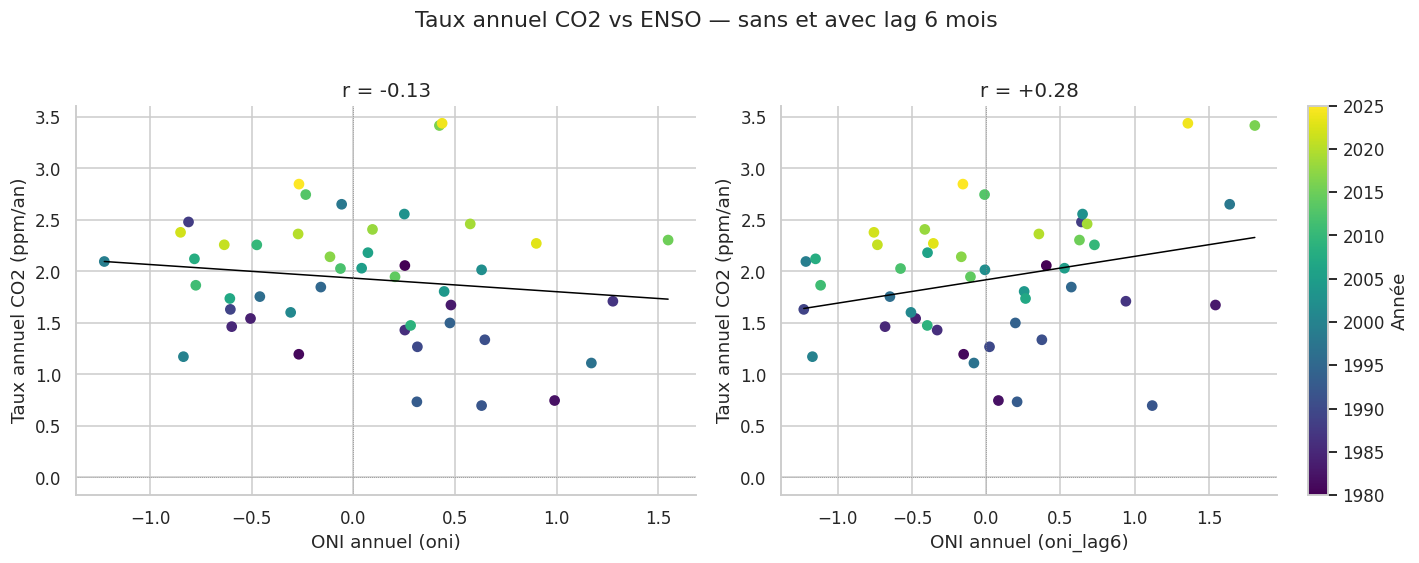

In [5]:
# Taux annuel de CO2
annual = (co2.groupby('year').agg(annual_mean=('average', 'mean'),
                                   n=('average', 'count')).reset_index())
annual = annual[annual['n'] >= 6].copy()
annual['rate'] = annual['annual_mean'].diff()

# ONI annuel + ONI annuel décalé de 6 mois
oni_dated = oni.assign(date=pd.to_datetime(dict(year=oni['year'], month=oni['month'], day=1)))
oni_dated = oni_dated.sort_values('date')
oni_dated['oni_lag6'] = oni_dated['oni'].shift(6)
oni_annual = oni_dated.groupby('year').agg(
    oni=('oni', 'mean'), oni_lag6=('oni_lag6', 'mean')).reset_index()

ar = annual.merge(oni_annual, on='year').dropna(subset=['rate'])
r_now = float(np.corrcoef(ar['rate'], ar['oni'])[0, 1])
r_lag = float(np.corrcoef(ar.dropna(subset=['oni_lag6'])['rate'],
                            ar.dropna(subset=['oni_lag6'])['oni_lag6'])[0, 1])
print(f"Corrélation taux CO2 ↔ ONI annuel (lag 0)  : {r_now:+.3f}")
print(f"Corrélation taux CO2 ↔ ONI annuel (lag 6 m): {r_lag:+.3f}  ← signal physique")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, r_val, sub in [
    (axes[0], 'oni',      r_now, ar),
    (axes[1], 'oni_lag6', r_lag, ar.dropna(subset=['oni_lag6']))]:
    sc = ax.scatter(sub[col], sub['rate'], c=sub['year'], cmap='viridis')
    p = np.polyfit(sub[col], sub['rate'], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 10)
    ax.plot(xs, np.polyval(p, xs), color='black', lw=1)
    ax.axhline(0, ls=':', color='grey', lw=0.5)
    ax.axvline(0, ls=':', color='grey', lw=0.5)
    ax.set_xlabel(f"ONI annuel ({col})")
    ax.set_ylabel('Taux annuel CO2 (ppm/an)')
    ax.set_title(f"r = {r_val:+.2f}")
fig.suptitle('Taux annuel CO2 vs ENSO — sans et avec lag 6 mois', y=1.02)
fig.tight_layout()
fig.colorbar(sc, ax=axes[1], label='Année')

## 7. Effet COVID-19 sur 2020-2021

**Hypothèse** : la baisse soudaine des émissions fossiles en 2020 a-t-elle
laissé une trace mesurable dans l'atmosphère ?

**Méthode** : modèle SARIMA(1,1,1)(0,1,1,12) ajusté sur **1979-2019** uniquement,
puis projeté pour 2020-2021. Comparaison observé vs contrefactuel.

/home/mazzez/Bureau/ESSAI/1er année/Programmation Mathematique/Projet/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/mazzez/Bureau/ESSAI/1er année/Programmation Mathematique/Projet/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/mazzez/Bureau/ESSAI/1er année/Programmation Mathematique/Projet/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Anomalie cumulée 2020-2021 (observé − contrefactuel) : -0.43 ppm


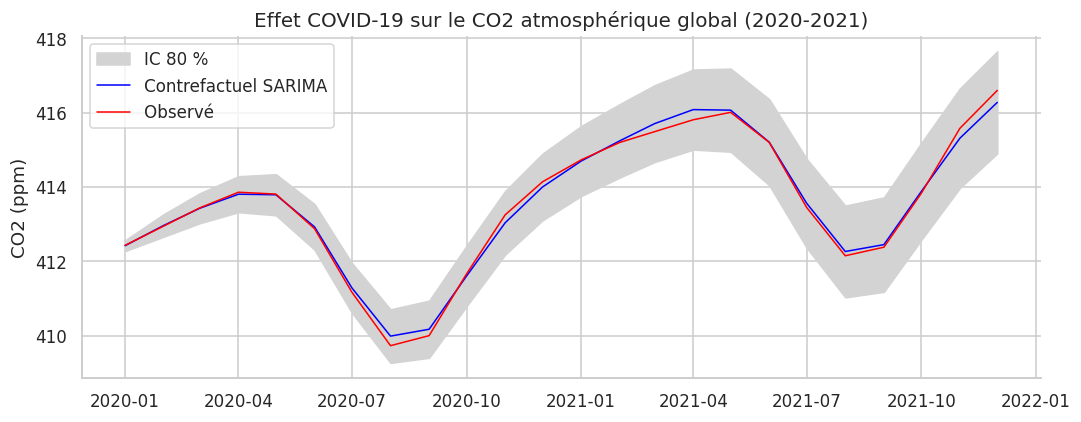

In [6]:
from statsmodels.tsa.arima.model import ARIMA
co2_idx = co2.set_index('date')
co2_pre = co2_idx.loc[:'2019-12-31', 'average']
fit = ARIMA(co2_pre, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
            enforce_stationarity=False, enforce_invertibility=False)
fit = fit.fit(method_kwargs={'warn_convergence': False})
fcst = fit.get_forecast(steps=24)
mean, ci80 = fcst.predicted_mean, fcst.conf_int(alpha=0.2)
obs = co2_idx.loc['2020-01-01':'2021-12-01', 'average']
anom_cumul = float((obs.values - mean.values).sum())
print(f"Anomalie cumulée 2020-2021 (observé − contrefactuel) : {anom_cumul:+.2f} ppm")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(mean.index, ci80.iloc[:, 0], ci80.iloc[:, 1], color='lightgrey', label='IC 80 %')
ax.plot(mean.index, mean,        color='blue', lw=1, label='Contrefactuel SARIMA')
ax.plot(obs.index,  obs.values,  color='red',  lw=1, label='Observé')
ax.legend()
ax.set_ylabel('CO2 (ppm)')
ax.set_title('Effet COVID-19 sur le CO2 atmosphérique global (2020-2021)')
fig.tight_layout()

**Conclusion §7** : l'anomalie cumulée est très faible et reste dans la bande d'IC 80 %
du contrefactuel. Le confinement a réduit les **émissions** d'environ 6 % en 2020,
mais l'**accumulation** atmosphérique dépend du flux *cumulé* — pas mesurable
statistiquement à l'échelle annuelle sur un seul événement.

## 8. Perspective paléo : Vostok

La carotte glaciaire de **Vostok** (Antarctique) retrace 414 000 ans de CO2.
Sur cette fenêtre, la hausse maximale paléo a été d'environ **6 ppm/siècle**
(transitions glaciaires-interglaciaires). Le taux moderne est de **185 ppm/siècle**.

Taux paléo maximal       : 6.04 ppm/siècle
Taux moderne (1979-2025) : 185.00 ppm/siècle  ← 31× plus rapide


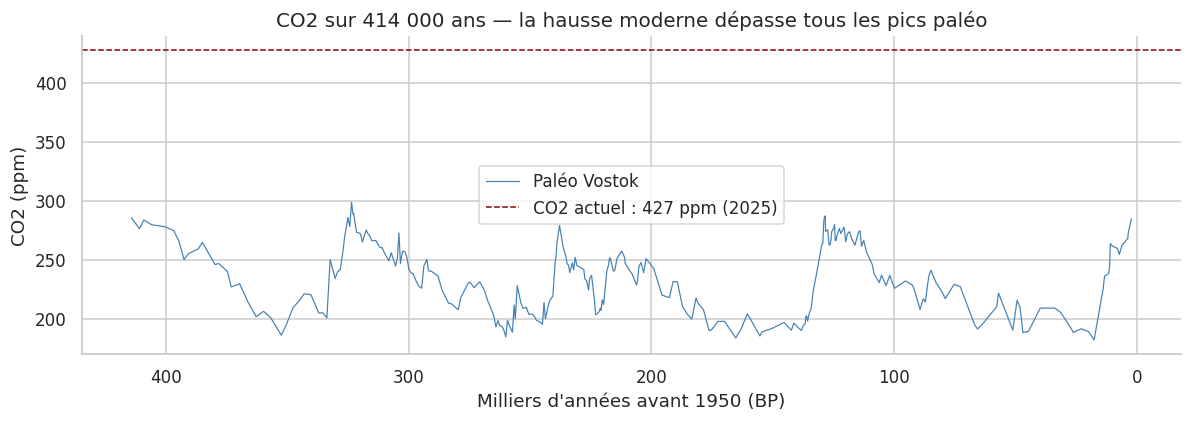

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vostok['gas_ageBP'] / 1000, vostok['CO2'],
        color='steelblue', lw=0.8, label='Paléo Vostok')
co2_now = float(co2['average'].iloc[-1])
ax.axhline(co2_now, ls='--', color='darkred', lw=1,
           label=f'CO2 actuel : {co2_now:.0f} ppm (2025)')
ax.invert_xaxis()
ax.set_xlabel('Milliers d\'années avant 1950 (BP)')
ax.set_ylabel('CO2 (ppm)')
ax.set_title('CO2 sur 414 000 ans — la hausse moderne dépasse tous les pics paléo')
ax.legend()
fig.tight_layout()

# Taux paléo vs moderne
v = vostok.copy()
v['d_age'] = v['gas_ageBP'].diff()
v['d_co2'] = v['CO2'].diff()
v['rate_per_century'] = (-v['d_co2'] / v['d_age']) * 100
max_paleo = float(v['rate_per_century'].max())
modern    = 1.85 * 100
print(f"Taux paléo maximal       : {max_paleo:.2f} ppm/siècle")
print(f"Taux moderne (1979-2025) : {modern:.2f} ppm/siècle  ← {modern/max_paleo:.0f}× plus rapide")

## 9. Synthèse et regard critique

### Résultats robustes
* **Trajectoire** : +86 ppm en 47 ans, Sen = 1.881 ppm/an [IC 95 % 1.78 – 1.97].
* **Forme** : cubique (AIC), bien capturée par un modèle exponentiel r = 0.5%/an.
* **Cycle saisonnier** : ratio NH/SH = 5.6× → la biosphère NH domine.
* **ENSO** : corrélation taux annuel ↔ ONI(lag 6 mois) = +0.28.
* **Vostok** : la hausse moderne est **30× plus rapide** que tout pic paléo connu.

### Limites identifiées
1. **STL et NOAA trend** : décompositions un peu trop lissées sur les derniers mois ;
   les valeurs récentes risquent d'être révisées (recommandation : ne pas faire de
   prévision au-delà de 24 mois).
2. **ENSO lag 6 mois** : valeur du R brouillée par les éruptions volcaniques
   (Pinatubo 1991, Hunga Tonga 2022) → la modulation réelle est probablement
   plus forte que 0.28 hors événements ponctuels.
3. **Effet COVID** : l'absence de signal statistique ne signifie pas absence physique ;
   simplement la **résolution temporelle annuelle** n'est pas adaptée à un événement
   de quelques mois.

### Pour aller plus loin
* **Phase 2-4** (`03_phase2_climat_25.ipynb`) : lien climat → CO2 sur 21 variables globales.
* **Phase 5** (`04_phase3_climat_05.ipynb`) : distribution spatiale du réchauffement.